# E-Commerce sales Analysis

### 📊 E-commerce Sales Prediction Dataset – Introduction

This dataset is a synthetically generated e-commerce sales dataset created for practicing data analysis, visualization, and machine learning modeling. It is designed to simulate realistic e-commerce sales patterns.

The dataset contains **1,000 records** from **January 1, 2023 to December 31, 2023**, with no missing values. It includes the following features:

* **Date** - Transaction date
* **Product_Category** - Electronics, Sports, Other
* **Price** - Product price (244–999)
* **Discount** - Discount percentage (0.01%–49.92%)
* **Customer_Segment** -  Regular, Occasional, Other
* **Marketing_Spend** - Marketing budget (2.41k–10k)
* **Units_Sold** - Number of units sold (5–57)

The data was generated using Python libraries such as **NumPy** and **Pandas**, ensuring realistic distributions and logical relationships (e.g., higher discounts or marketing spend generally lead to higher units sold).

This dataset is suitable for:

1. **Price Distribution:** Histogram to show the spread of prices.
2. **Discount Distribution:** Histogram to analyze promotional offers.
3. **Marketing Spend Distribution:** Histogram to understand marketing investment patterns.
4. **Customer Segment Distribution:** Bar plot of customer segments.
5. **Price vs Units Sold:** Scatter plot to show pricing effects on sales.
6. **Discount vs Units Sold:** Scatter plot to explore the impact of discounts.
7. **Marketing Spend vs Units Sold:** Scatter plot for marketing effectiveness.
8. **Correlation Heatmap:** Identify relationships between features.
9. **Pairplot:** Visualize pairwise feature interactions.



Dataset source: **nevildhinoja/e-commerce-sales-prediction-dataset**.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
import seaborn as sns


In [5]:
#df = pd.read_csv("/kaggle/input/e-commerce-sales-prediction-dataset/Ecommerce_Sales_Prediction_Dataset.csv")
df = pd.read_csv("Ecommerce_Sales.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1000 non-null   object 
 1   Product_Category  1000 non-null   object 
 2   Price             1000 non-null   float64
 3   Discount          1000 non-null   float64
 4   Customer_Segment  1000 non-null   object 
 5   Marketing_Spend   1000 non-null   float64
 6   Units_Sold        1000 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 54.8+ KB


In [7]:
df.head(10)

,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold
0,01-01-2023,Sports,932.80,35.82,Occasional,6780.38,32
1,02-01-2023,Toys,569.48,3.60,Premium,6807.56,16
2,03-01-2023,Home Decor,699.68,3.56,Premium,3793.91,27
3,04-01-2023,Toys,923.27,0.61,Premium,9422.75,29
4,05-01-2023,Toys,710.17,47.83,Premium,1756.83,17
5,06-01-2023,Fashion,161.01,36.88,Premium,5053.56,27
6,07-01-2023,Home Decor,580.53,17.66,Occasional,6939.75,30
7,08-01-2023,Home Decor,610.65,14.83,Regular,7001.64,27
8,09-01-2023,Home Decor,429.89,17.49,Occasional,6521.53,32
9,10-01-2023,Toys,739.08,38.73,Regular,2825.35,28


In [9]:
df.shape

(1000, 7)

In [11]:
df.describe()

,Price,Discount,Marketing_Spend,Units_Sold
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,505.241920,24.919750,4912.830240,29.631000
std,289.791248,14.439951,2840.602656,7.267989
min,14.590000,0.010000,100.300000,5.000000
25%,243.342500,12.995000,2413.020000,24.000000
50%,509.310000,24.965000,4837.245000,30.000000
75%,747.592500,37.562500,7319.675000,34.000000
max,999.420000,49.920000,9995.620000,57.000000


In [19]:
df.isnull().sum()

Date                0
Product_Category    0
Price               0
Discount            0
Customer_Segment    0
Marketing_Spend     0
Units_Sold          0
dtype: int64

In [21]:
df['Date'].head()

0   2023-01-01
1   2023-01-02
2   2023-01-03
3   2023-01-04
4   2023-01-05
Name: Date, dtype: datetime64[ns]

In [22]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

In [52]:
df.groupby('Month')['Units_Sold'].sum()

Month
1     2679
2     2486
3     2740
4     2582
5     2819
6     2672
7     2784
8     2771
9     2523
10    1929
11    1796
12    1850
Name: Units_Sold, dtype: int64

In [53]:
df.groupby('Customer_Segment')['Units_Sold'].mean()

Customer_Segment
Occasional    29.032448
Premium       30.275316
Regular       29.628986
Name: Units_Sold, dtype: float64

In [54]:
df.groupby('Product_Category')['Units_Sold'].sum()


Product_Category
Electronics    6210
Fashion        5650
Home Decor     5643
Sports         6125
Toys           6003
Name: Units_Sold, dtype: int64

## Univariate analysis

### 1. Price Distribution

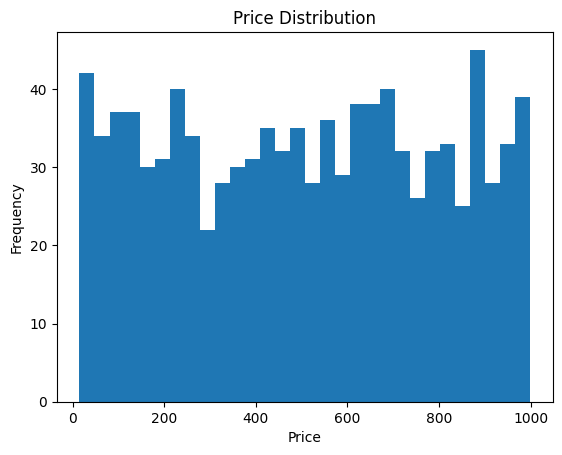

In [33]:
plt.figure()
plt.hist(df['Price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## 2. Discount Distribution

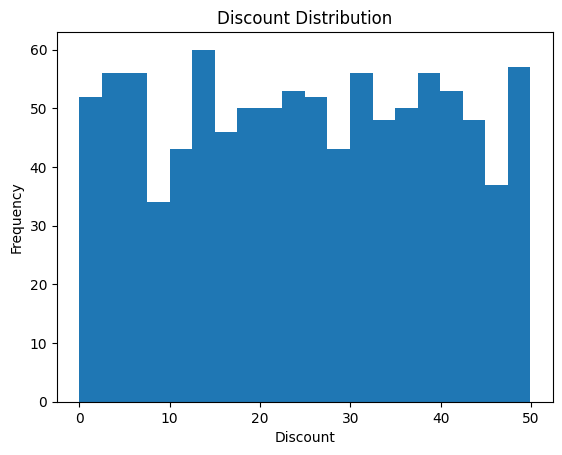

In [31]:
plt.figure()
plt.hist(df['Discount'], bins=20)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()


## 3. Market spend distribution

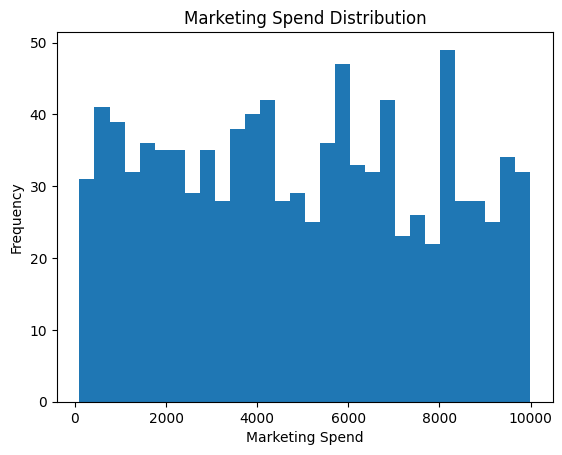

In [38]:
plt.figure()
plt.hist(df['Marketing_Spend'], bins=30)
plt.title("Marketing Spend Distribution")
plt.xlabel("Marketing Spend")
plt.ylabel("Frequency")
plt.show()


## 3. Customer segment Distribution

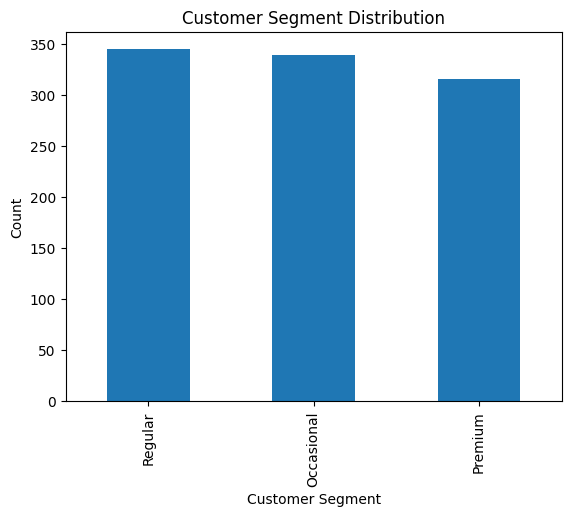

In [39]:
plt.figure()
df['Customer_Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.show()

# Bivariate Analysis

## 1. Price vs. Unit Sold

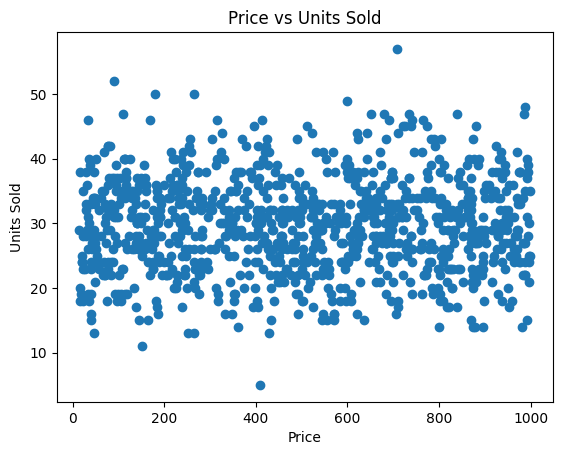

In [40]:
plt.figure()
plt.scatter(df['Price'], df['Units_Sold'])
plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.show()


## 2. Discount vs. Units Sold

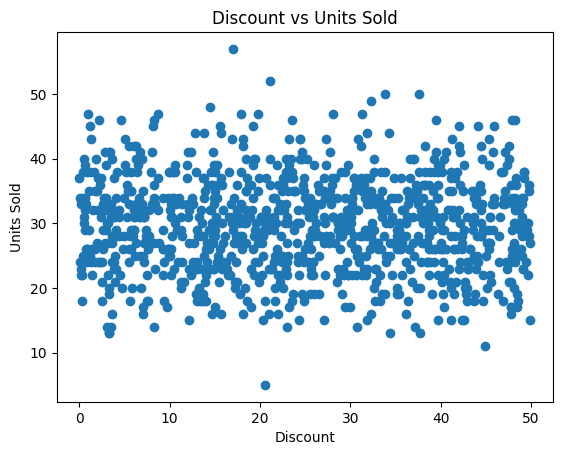

In [41]:
plt.figure()
plt.scatter(df['Discount'], df['Units_Sold'])
plt.title("Discount vs Units Sold")
plt.xlabel("Discount")
plt.ylabel("Units Sold")
plt.show()


## 3. Market spend vs. Unit Sold

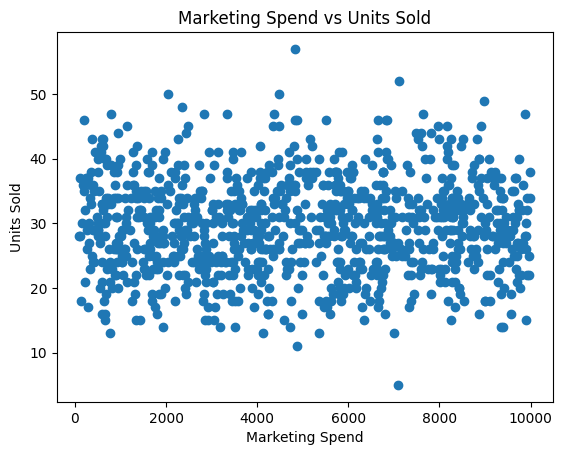

In [42]:
plt.figure()
plt.scatter(df['Marketing_Spend'], df['Units_Sold'])
plt.title("Marketing Spend vs Units Sold")
plt.xlabel("Marketing Spend")
plt.ylabel("Units Sold")
plt.show()


# Category based analysis

## 1. Units sold by Product Category

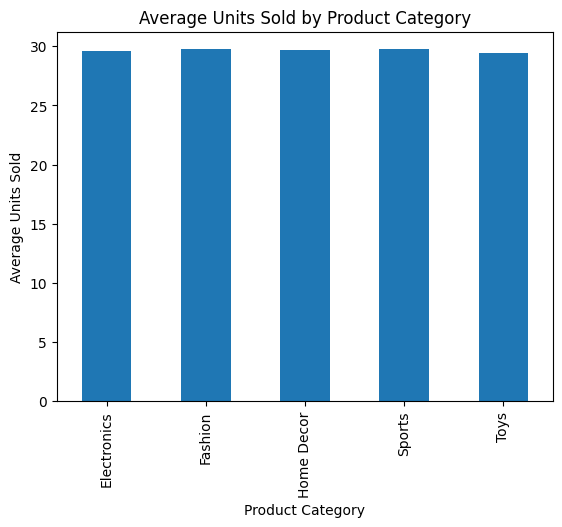

In [43]:
plt.figure()
df.groupby('Product_Category')['Units_Sold'].mean().plot(kind='bar')
plt.title("Average Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Units Sold")
plt.show()


## 2. Units sold by Customer segment

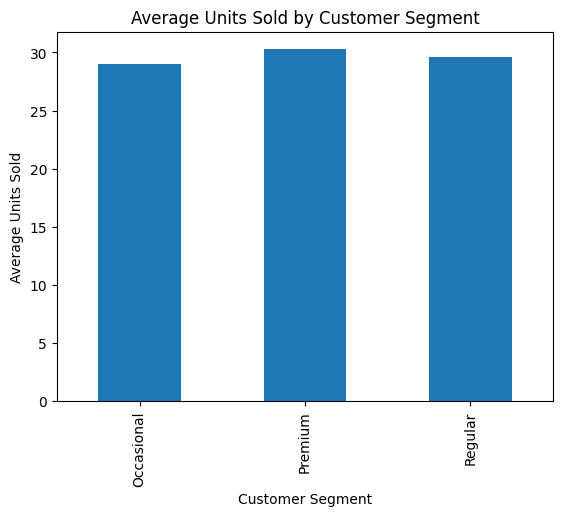

In [44]:
plt.figure()
df.groupby('Customer_Segment')['Units_Sold'].mean().plot(kind='bar')
plt.title("Average Units Sold by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Units Sold")
plt.show()


## Correlation Analysis


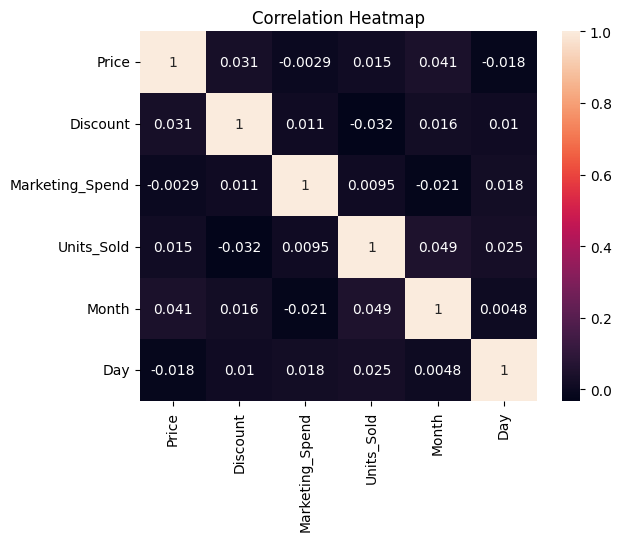

In [45]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


# PairPlot

In [48]:
df.columns

Index(['Date', 'Product_Category', 'Price', 'Discount', 'Customer_Segment',
       'Marketing_Spend', 'Units_Sold', 'Month', 'Day', 'Weekday'],
      dtype='object')

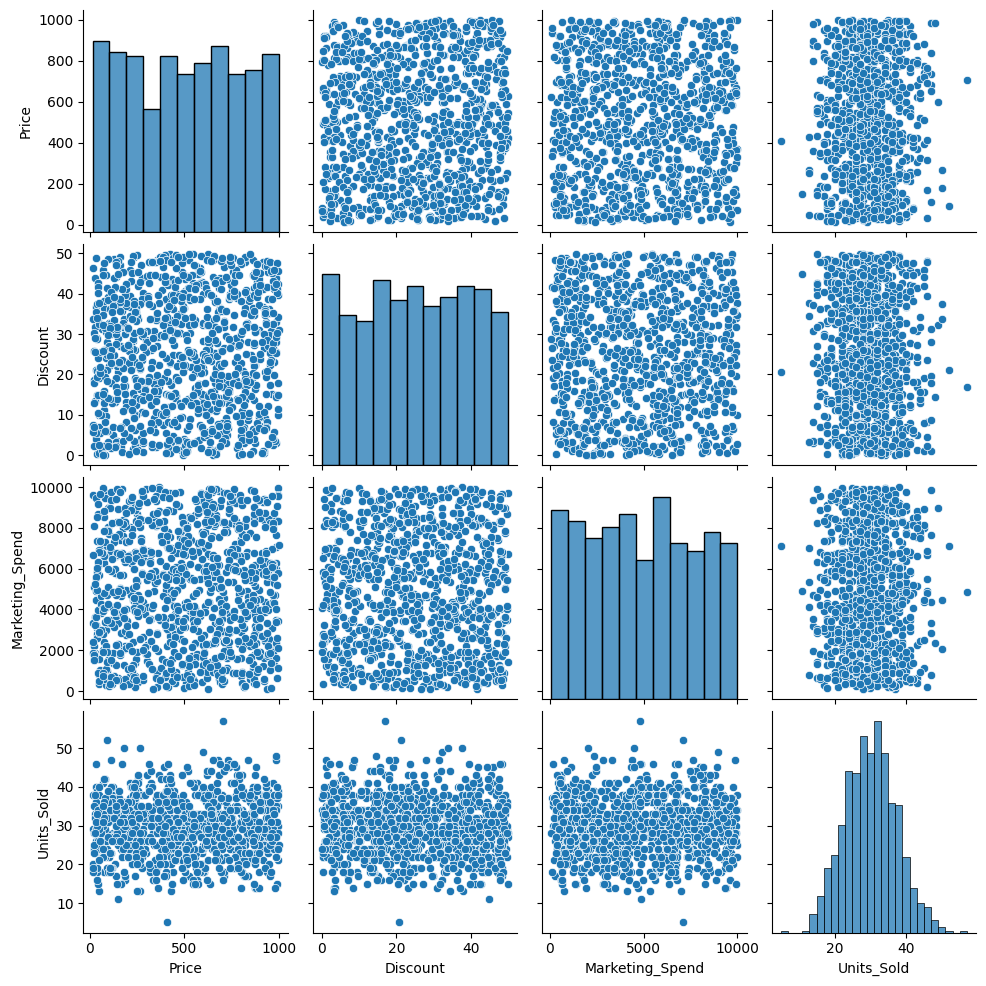

In [49]:
sns.pairplot(df[['Price', 'Discount', 'Marketing_Spend', 'Units_Sold']])
plt.show()

## Monthly Sales Trend

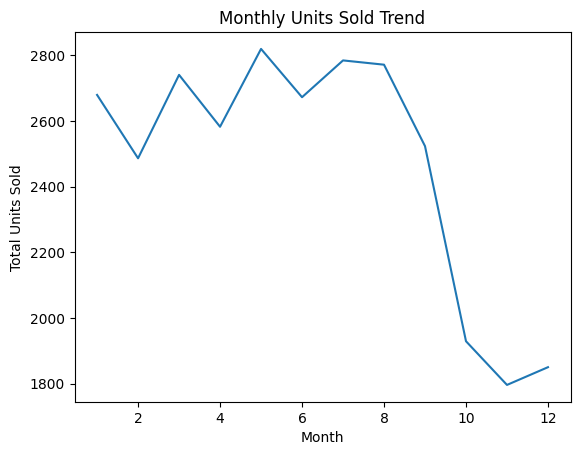

In [50]:
monthly_sales = df.groupby('Month')['Units_Sold'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.show()
